# Bevölkerung nach Bildungsstand, Jahr, Alter und Geschlecht

bfs_bev_bildungsstand_alter_geschl_seit1970_od1005

### Kurzbeschreibung
Diese Daten beschreiben die ständige Wohnbevölkerung der Stadt Zürich und basieren auf der Volkszählung und der Strukturerhebung des Bundesamts für Statistik.

Es sind bloss 15-jährige und ältere Personen enthalten. Weitere Informationen finden Sie unter Bemerkung.

Datum: 03.03.2025


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_bev_bildungsstand_alter_geschl_seit1970_od1005

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bev_bildungsstand_alter_geschl_seit1970_od1005


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [3]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [4]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [5]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [6]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [7]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [8]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [9]:
package_name = "bfs_bev_bildungsstand_alter_geschl_seit1970_od1005"

In [10]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BIL100OD1005"    
    , datums_attr = ['Jahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bev_bildungsstand_alter_geschl_seit1970_od1005/download/BIL100OD1005.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bev_bildungsstand_alter_geschl_seit1970_od1005 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bfs_bev_bildungsstand_alter_geschl_seit1970_od1005 

data_source: web


In [11]:
data2betested.head(2).T

,0,1
Jahr,1970-01-01 00:00:00,1970-01-01 00:00:00
Geschlecht,Total,Total
AlterV10_15ueber75Lang_noDM,15 bis 24,15 bis 24
Bildungsstand,Ohne nachobligatorische Ausbildung,Sekundarstufe II
AntBev,31,64
untAntBevKI,NaN,NaN
obAntBevKI,NaN,NaN


Berechne weitere Attribute falls notwendig

In [12]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.Jahr.astype(str),
        Jahr_end = lambda x: x.Jahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('Jahr_end', ascending=False)
    )
data2betested.dtypes

Jahr                           datetime64[ns]
Geschlecht                             object
AlterV10_15ueber75Lang_noDM            object
Bildungsstand                          object
AntBev                                float64
untAntBevKI                           float64
obAntBevKI                            float64
StichtagDatJahr_str                    object
Jahr_end                       datetime64[ns]
Jahr_nbr                                int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [13]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1970-12-31 und ein Maximumjahr von 2023-12-31


### Einfache Datentests

In [14]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1134 entries, 1133 to 0
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Jahr                         1134 non-null   datetime64[ns]
 1   Geschlecht                   1134 non-null   object        
 2   AlterV10_15ueber75Lang_noDM  1134 non-null   object        
 3   Bildungsstand                1134 non-null   object        
 4   AntBev                       1134 non-null   float64       
 5   untAntBevKI                  882 non-null    float64       
 6   obAntBevKI                   882 non-null    float64       
 7   StichtagDatJahr_str          1134 non-null   object        
 8   Jahr_end                     1134 non-null   datetime64[ns]
 9   Jahr_nbr                     1134 non-null   int32         
dtypes: datetime64[ns](2), float64(3), int32(1), object(4)
memory usage: 382.3 KB


In [15]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 1,134 rows (observations) and 10 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [16]:
data2betested.describe()

,Jahr,AntBev,untAntBevKI,obAntBevKI,Jahr_end,Jahr_nbr
count,1134,1134,882,882,1134,1134
mean,2009-07-02 05:20:00,33,30,36,2010-07-01 12:00:00,2010
min,1970-01-01 00:00:00,3,3,5,1970-12-31 00:00:00,1970
25%,2010-01-01 00:00:00,19,16,21,2010-12-31 00:00:00,2010
50%,2014-07-02 12:00:00,31,28,34,2015-07-01 12:00:00,2014
75%,2019-01-01 00:00:00,46,42,50,2019-12-31 00:00:00,2019
max,2023-01-01 00:00:00,79,77,82,2023-12-31 00:00:00,2023
std,NaN,18,18,18,NaN,15


Welches sind die Quartiere ohne Werte bei BEW?

In [17]:
data2betested[np.isnan(data2betested.AntBev)]

,Jahr,Geschlecht,AlterV10_15ueber75Lang_noDM,Bildungsstand,AntBev,untAntBevKI,obAntBevKI,StichtagDatJahr_str,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [18]:
data2betested = data2betested.set_index("Jahr_end")
data2betested = data2betested.sort_index()

In [19]:
data2betested.index.year.unique()

Index([1970, 1980, 1990, 2000, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023],
      dtype='int32', name='Jahr_end')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [20]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,Jahr,Geschlecht,AlterV10_15ueber75Lang_noDM,Bildungsstand,StichtagDatJahr_str
count,1134,1134,1134,1134,1134
unique,NaN,3,7,3,18
top,NaN,Total,15 bis 24,Ohne nachobligatorische Ausbildung,1970-01-01
freq,NaN,378,162,378,63
mean,2009-07-02 05:20:00,NaN,NaN,NaN,NaN
min,1970-01-01 00:00:00,NaN,NaN,NaN,NaN
25%,2010-01-01 00:00:00,NaN,NaN,NaN,NaN
50%,2014-07-02 12:00:00,NaN,NaN,NaN,NaN
75%,2019-01-01 00:00:00,NaN,NaN,NaN,NaN
max,2023-01-01 00:00:00,NaN,NaN,NaN,NaN


Beschreibe numerische Attribute

In [21]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,AntBev,untAntBevKI,obAntBevKI,Jahr_nbr
count,"1,134",882,882,"1,134"
mean,33,30,36,"2,010"
std,18,18,18,15
min,3,3,5,"1,970"
25%,19,16,21,"2,010"
50%,31,28,34,"2,014"
75%,46,42,50,"2,019"
max,79,77,82,"2,023"


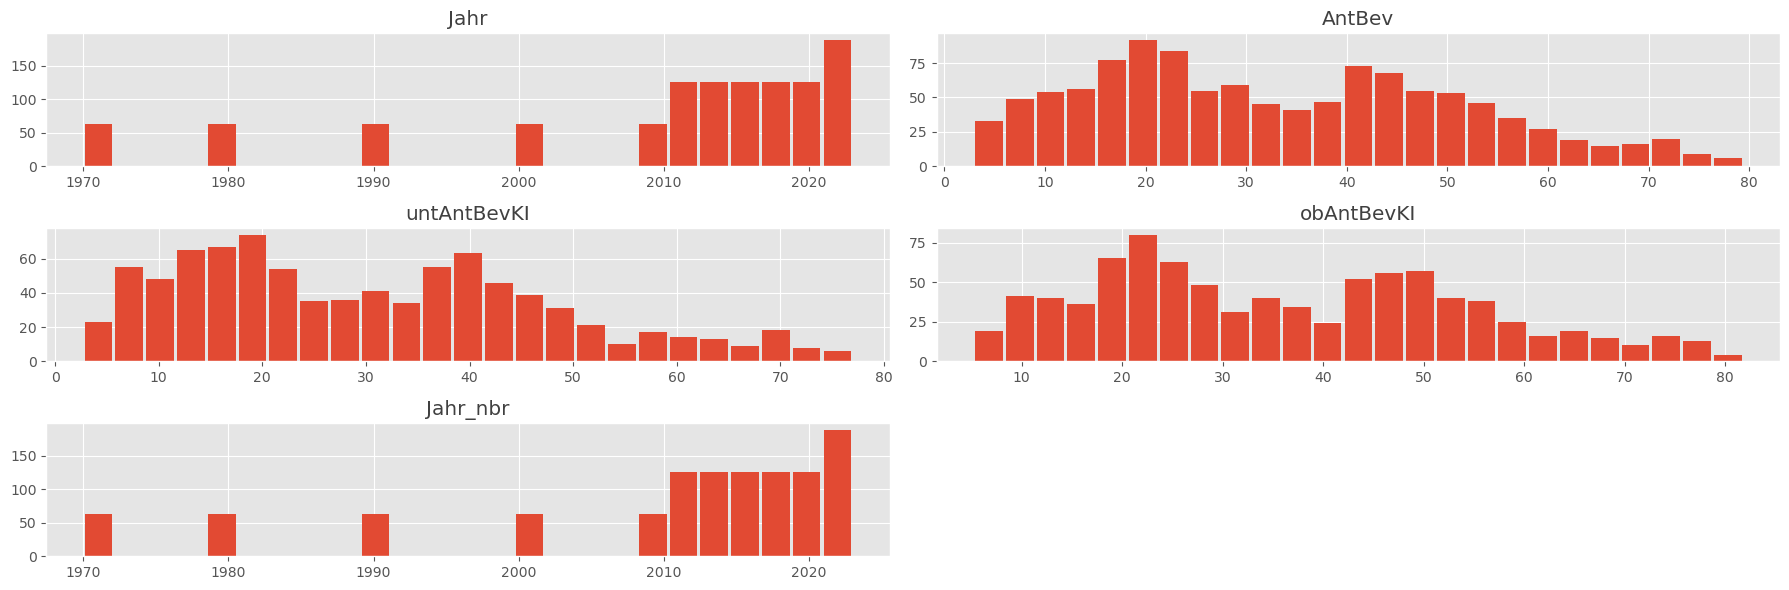

In [22]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [23]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,Jahr,Geschlecht,AlterV10_15ueber75Lang_noDM,Bildungsstand,AntBev,untAntBevKI,obAntBevKI,StichtagDatJahr_str,Jahr_nbr
Jahr_end,,,,,,,,,


### Nullwerte und Missings?

In [24]:
data2betested.isnull().sum()

Jahr                             0
Geschlecht                       0
AlterV10_15ueber75Lang_noDM      0
Bildungsstand                    0
AntBev                           0
untAntBevKI                    252
obAntBevKI                     252
StichtagDatJahr_str              0
Jahr_nbr                         0
dtype: int64

In [25]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [26]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr']) \
    .agg(mean_AntBev=('AntBev', 'mean'),median_AntBev=('AntBev', 'median')
    , mean_untAntBevKI=('untAntBevKI', 'mean'),median_untAntBevKI=('untAntBevKI', 'median')
    , mean_obAntBevKI=('obAntBevKI', 'mean'),median_obAntBevKI=('obAntBevKI', 'median')
    ) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,mean_AntBev,median_AntBev,mean_untAntBevKI,median_untAntBevKI,mean_obAntBevKI,median_obAntBevKI
0,2023-01-01,2023,33,27,30,23,36,31
1,2022-01-01,2022,33,30,30,26,36,34
2,2021-01-01,2021,33,30,30,26,36,34


In [27]:
agg_bildungsstand = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Bildungsstand']) \
    .agg(mean_AntBev=('AntBev', 'mean'),median_AntBev=('AntBev', 'median')
    , mean_untAntBevKI=('untAntBevKI', 'mean'),median_untAntBevKI=('untAntBevKI', 'median')
    , mean_obAntBevKI=('obAntBevKI', 'mean'),median_obAntBevKI=('obAntBevKI', 'median')
    ) \
    .sort_values('Bildungsstand', ascending=False) 
agg_bildungsstand.reset_index().head(3)

,Bildungsstand,mean_AntBev,median_AntBev,mean_untAntBevKI,median_untAntBevKI,mean_obAntBevKI,median_obAntBevKI
0,Tertiärstufe,36,34,39,38,45,46
1,Sekundarstufe II,41,43,34,35,41,42
2,Ohne nachobligatorische Ausbildung,23,21,18,16,24,21


In [47]:
agg_age = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['AlterV10_15ueber75Lang_noDM']) \
    .agg(mean_AntBev=('AntBev', 'mean'),median_AntBev=('AntBev', 'median')
    , mean_untAntBevKI=('untAntBevKI', 'mean'),median_untAntBevKI=('untAntBevKI', 'median')
    , mean_obAntBevKI=('obAntBevKI', 'mean'),median_obAntBevKI=('obAntBevKI', 'median')
    ) \
    .sort_values('AlterV10_15ueber75Lang_noDM', ascending=False) 
agg_age.reset_index().head(10)

,AlterV10_15ueber75Lang_noDM,mean_AntBev,median_AntBev,mean_untAntBevKI,median_untAntBevKI,mean_obAntBevKI,median_obAntBevKI
0,75 und älter,33,33,30,28,37,36
1,65 bis 74,33,32,30,28,37,35
2,55 bis 64,33,34,30,31,36,38
3,45 bis 54,33,32,31,30,36,35
4,35 bis 44,33,26,31,22,35,26
5,25 bis 34,33,24,31,21,35,25
6,15 bis 24,33,41,30,38,37,46


In [48]:
agg_gender = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Geschlecht']) \
    .agg(mean_AntBev=('AntBev', 'mean'),median_AntBev=('AntBev', 'median')
    , mean_untAntBevKI=('untAntBevKI', 'mean'),median_untAntBevKI=('untAntBevKI', 'median')
    , mean_obAntBevKI=('obAntBevKI', 'mean'),median_obAntBevKI=('obAntBevKI', 'median')
    ) \
    .sort_values('Geschlecht', ascending=False) 
agg_gender.reset_index().head(10)

,Geschlecht,mean_AntBev,median_AntBev,mean_untAntBevKI,median_untAntBevKI,mean_obAntBevKI,median_obAntBevKI
0,Total,33,31,31,29,36,33
1,Männer,33,29,30,28,37,35
2,Frauen,33,33,30,28,36,34


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Wochenaufenthaltender nach Altersgruppe

In [29]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc["1970":data_max_date]\
    .groupby(['Jahr', 'Jahr_end', 'Bildungsstand']) \
    .agg(mean_AntBev=('AntBev', 'mean'), median_AntBev=('AntBev', 'sum'), mean_untAntBevKI=('untAntBevKI', 'mean'),median_untAntBevKI=('untAntBevKI', 'median'), mean_obAntBevKI=('obAntBevKI', 'mean'),median_obAntBevKI=('obAntBevKI', 'median')) \
    .sort_values('Jahr', ascending=False) 

myAgg1.reset_index().head(3)

,Jahr,Jahr_end,Bildungsstand,mean_AntBev,median_AntBev,mean_untAntBevKI,median_untAntBevKI,mean_obAntBevKI,median_obAntBevKI
0,2023-01-01,2023-12-31,Tertiärstufe,52,1088,48,50,55,58
1,2023-01-01,2023-12-31,Sekundarstufe II,30,630,27,26,33,31
2,2023-01-01,2023-12-31,Ohne nachobligatorische Ausbildung,18,382,15,12,21,20


In [49]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().sort_values('Bildungsstand', ascending=True)
    ,x = 'Jahr_end:T'
    ,y = 'AntBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anteil'
    ,category = "Bildungsstand:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung des Bildungsstands in der Stadt Zürich, seit "+data_min_date
)

grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().sort_values('Bildungsstand', ascending=True)
    ,x = 'Jahr_end:T'
    ,y = 'untAntBevKI:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anteil'
    ,category = "Bildungsstand:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung des Bildungsstands (unteres KI) in der Stadt Zürich, seit "+data_min_date
)

grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().sort_values('Bildungsstand', ascending=True)
    ,x = 'Jahr_end:T'
    ,y = 'obAntBevKI:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anteil'
    ,category = "Bildungsstand:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung des Bildungsstands (oberes KI) in der Stadt Zürich, seit "+data_min_date
)


##### Kombinierte Grafik in Altair

In [50]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik2)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik2, grafik3, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

In [30]:
data2betested.columns

Index(['Jahr', 'Geschlecht', 'AlterV10_15ueber75Lang_noDM', 'Bildungsstand', 'AntBev',
       'untAntBevKI', 'obAntBevKI', 'StichtagDatJahr_str', 'Jahr_nbr'],
      dtype='object')

#### Barcharts mit Seaborn

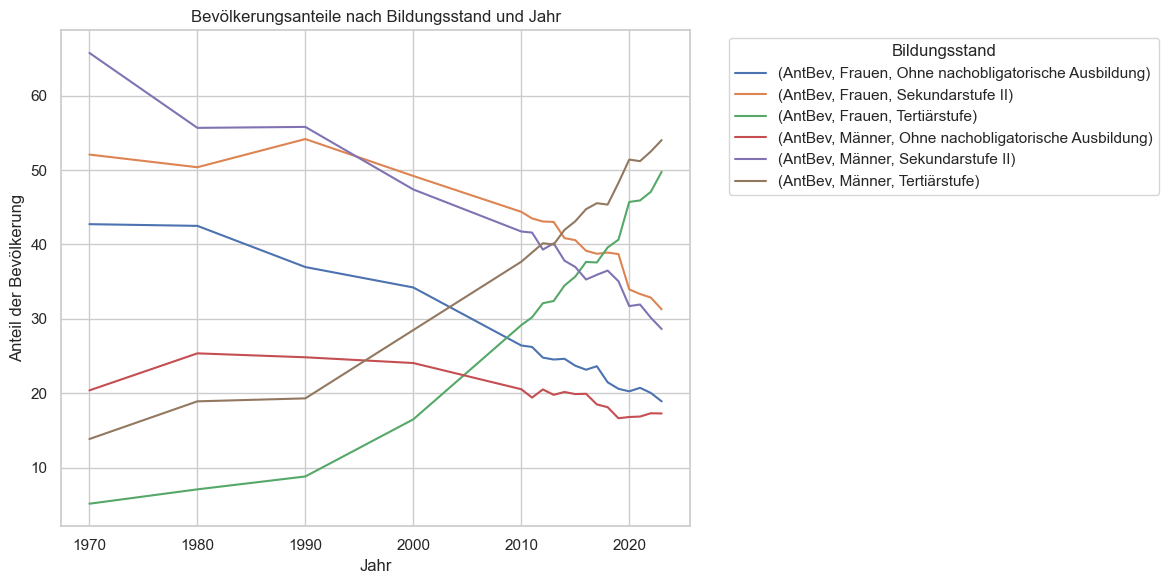

In [73]:

# Gruppieren Sie die Daten nach Jahr und Bildungsstand
grouped = data2betested.query('Geschlecht!= "Total"').pivot_table(values=['AntBev'], index='Jahr_nbr', columns=['Geschlecht','Bildungsstand'], aggfunc='mean')

# Erstellen Sie data2betested gruppierte Balkendiagramm
ax = grouped.plot(kind='line', figsize=(12, 6))

# Anpassen des Diagramms
plt.title('Bevölkerungsanteile nach Bildungsstand und Jahr')
plt.xlabel('Jahr')
plt.ylabel('Anteil der Bevölkerung')
plt.legend(title='Bildungsstand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [34]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")


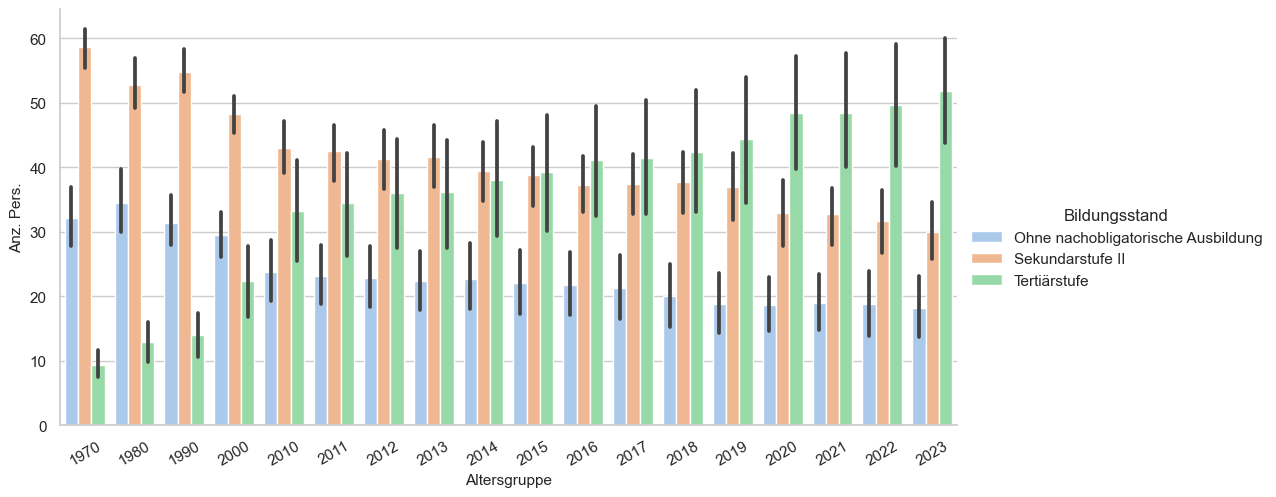

In [35]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="Jahr_nbr"
            , y="AntBev"
            , hue="Bildungsstand"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=data2betested.reset_index()
           )
myHist.set_xticklabels(rotation=30) 
myHist.set_xlabels('Altersgruppe', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


#### Faced Grids

In [36]:
data2betested.columns

Index(['Jahr', 'Geschlecht', 'AlterV10_15ueber75Lang_noDM', 'Bildungsstand', 'AntBev',
       'untAntBevKI', 'obAntBevKI', 'StichtagDatJahr_str', 'Jahr_nbr'],
      dtype='object')

In [54]:

melted_df = data2betested.reset_index().melt(id_vars=['Jahr_end', 'Bildungsstand', 'AlterV10_15ueber75Lang_noDM'], value_vars=['AntBev', 'untAntBevKI', 'obAntBevKI'])
melted_df



,Jahr_end,Bildungsstand,AlterV10_15ueber75Lang_noDM,variable,value
0,1970-12-31,Ohne nachobligatorische Ausbildung,15 bis 24,AntBev,31
1,1970-12-31,Sekundarstufe II,25 bis 34,AntBev,57
2,1970-12-31,Tertiärstufe,25 bis 34,AntBev,14
3,1970-12-31,Ohne nachobligatorische Ausbildung,35 bis 44,AntBev,33
4,1970-12-31,Sekundarstufe II,35 bis 44,AntBev,56
...,...,...,...,...,...
3397,2023-12-31,Ohne nachobligatorische Ausbildung,55 bis 64,obAntBevKI,21
3398,2023-12-31,Tertiärstufe,25 bis 34,obAntBevKI,78
3399,2023-12-31,Tertiärstufe,45 bis 54,obAntBevKI,67
3400,2023-12-31,Ohne nachobligatorische Ausbildung,45 bis 54,obAntBevKI,14


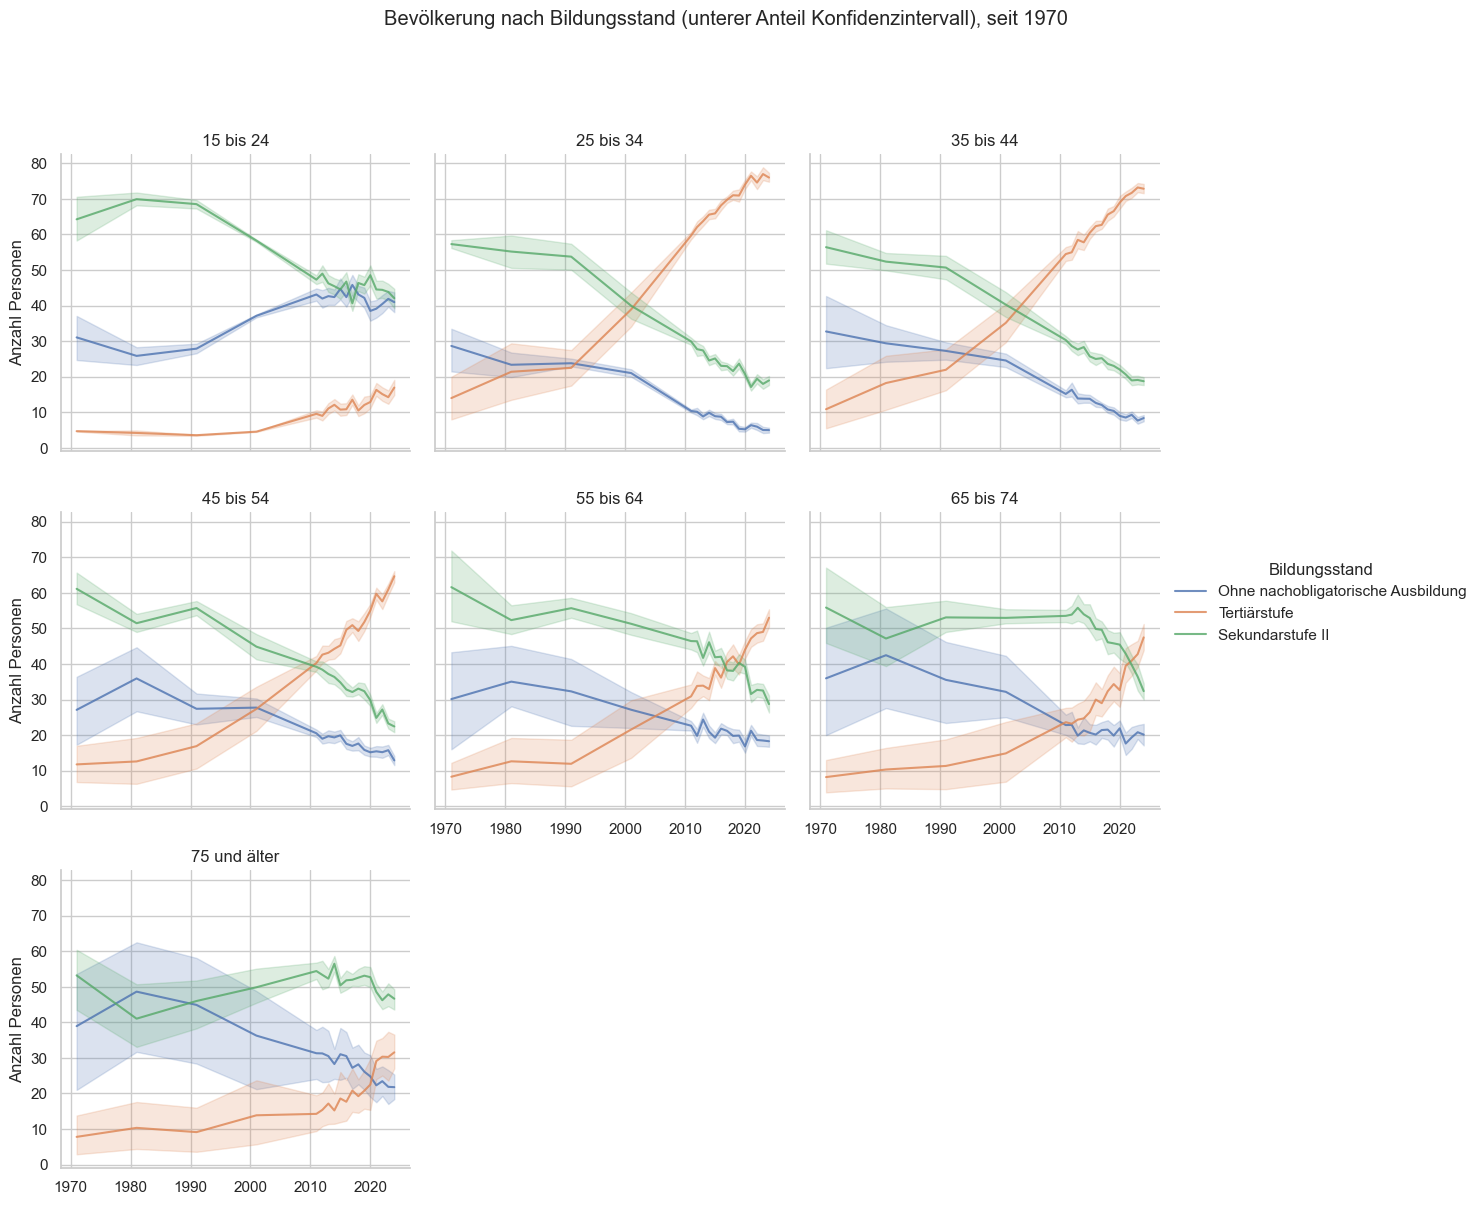

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = melted_df.reset_index().sort_values('AlterV10_15ueber75Lang_noDM', ascending=True)
    ,col = "AlterV10_15ueber75Lang_noDM"
    ,hue = "Bildungsstand"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_end"
    ,y = "value"
    ,ylabel= "Anteil"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Bevölkerung nach Bildungsstand, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

(<seaborn.axisgrid.FacetGrid at 0x254f4da7b50>,
 <seaborn.axisgrid.FacetGrid at 0x254f12c0610>)

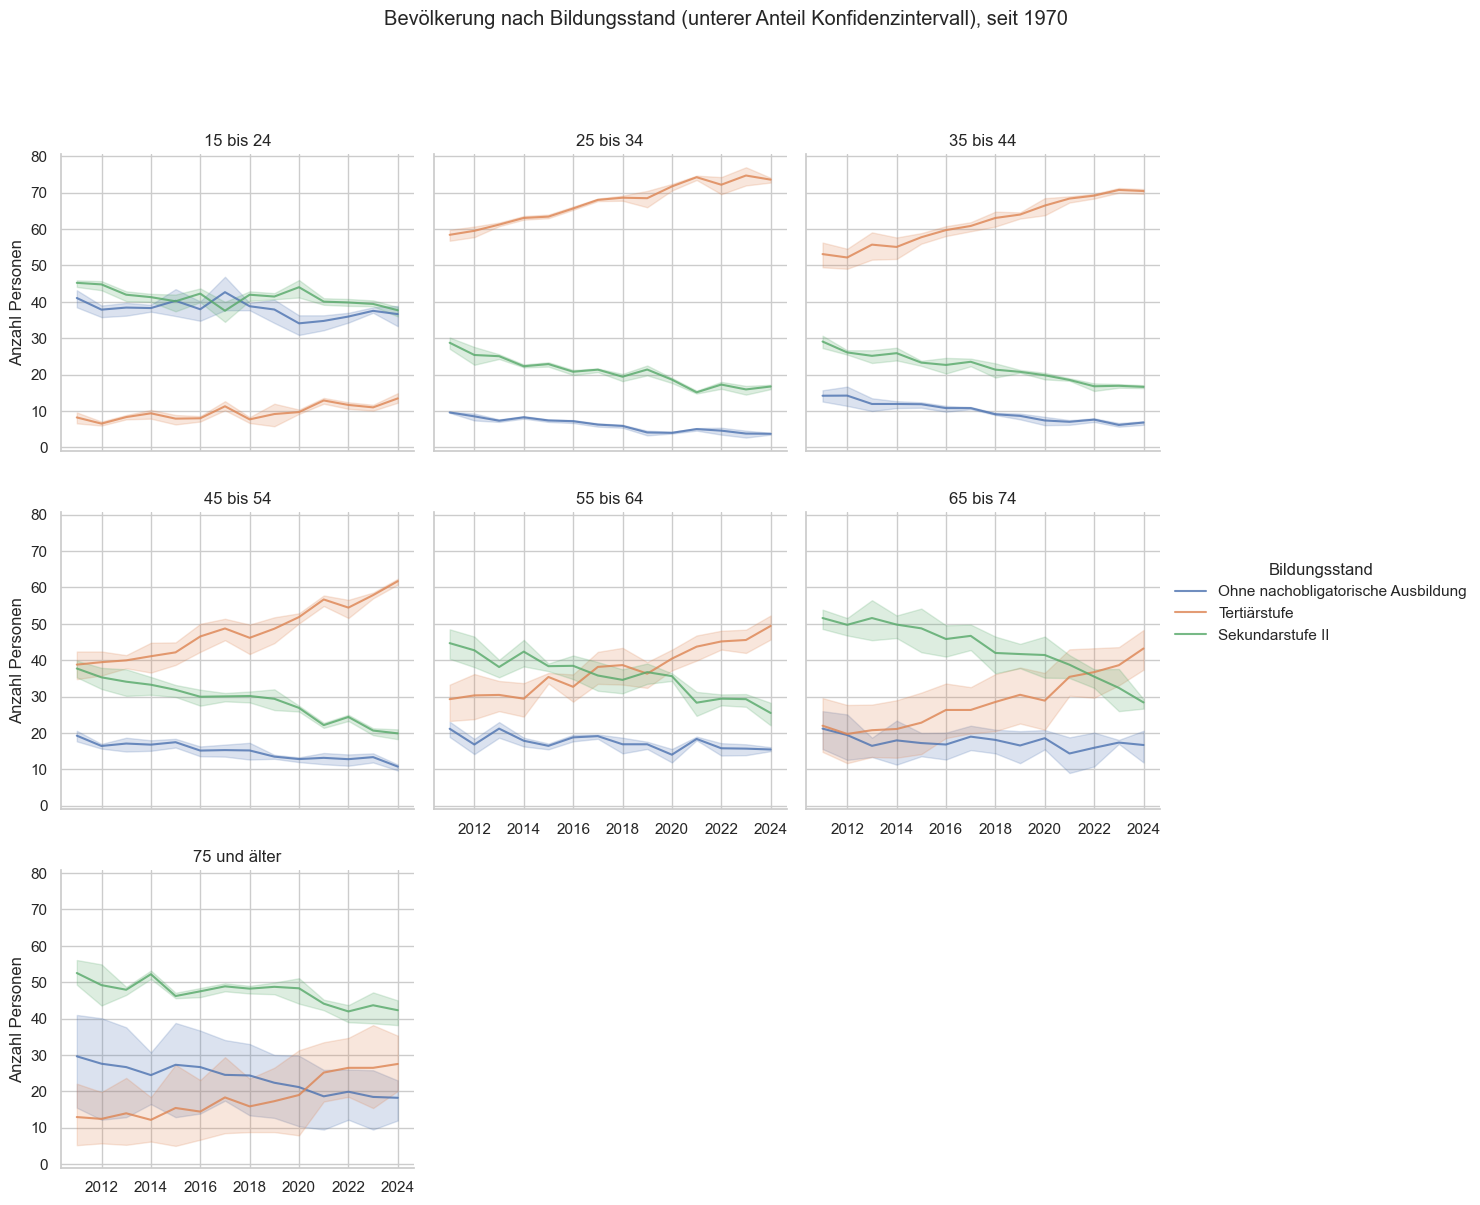

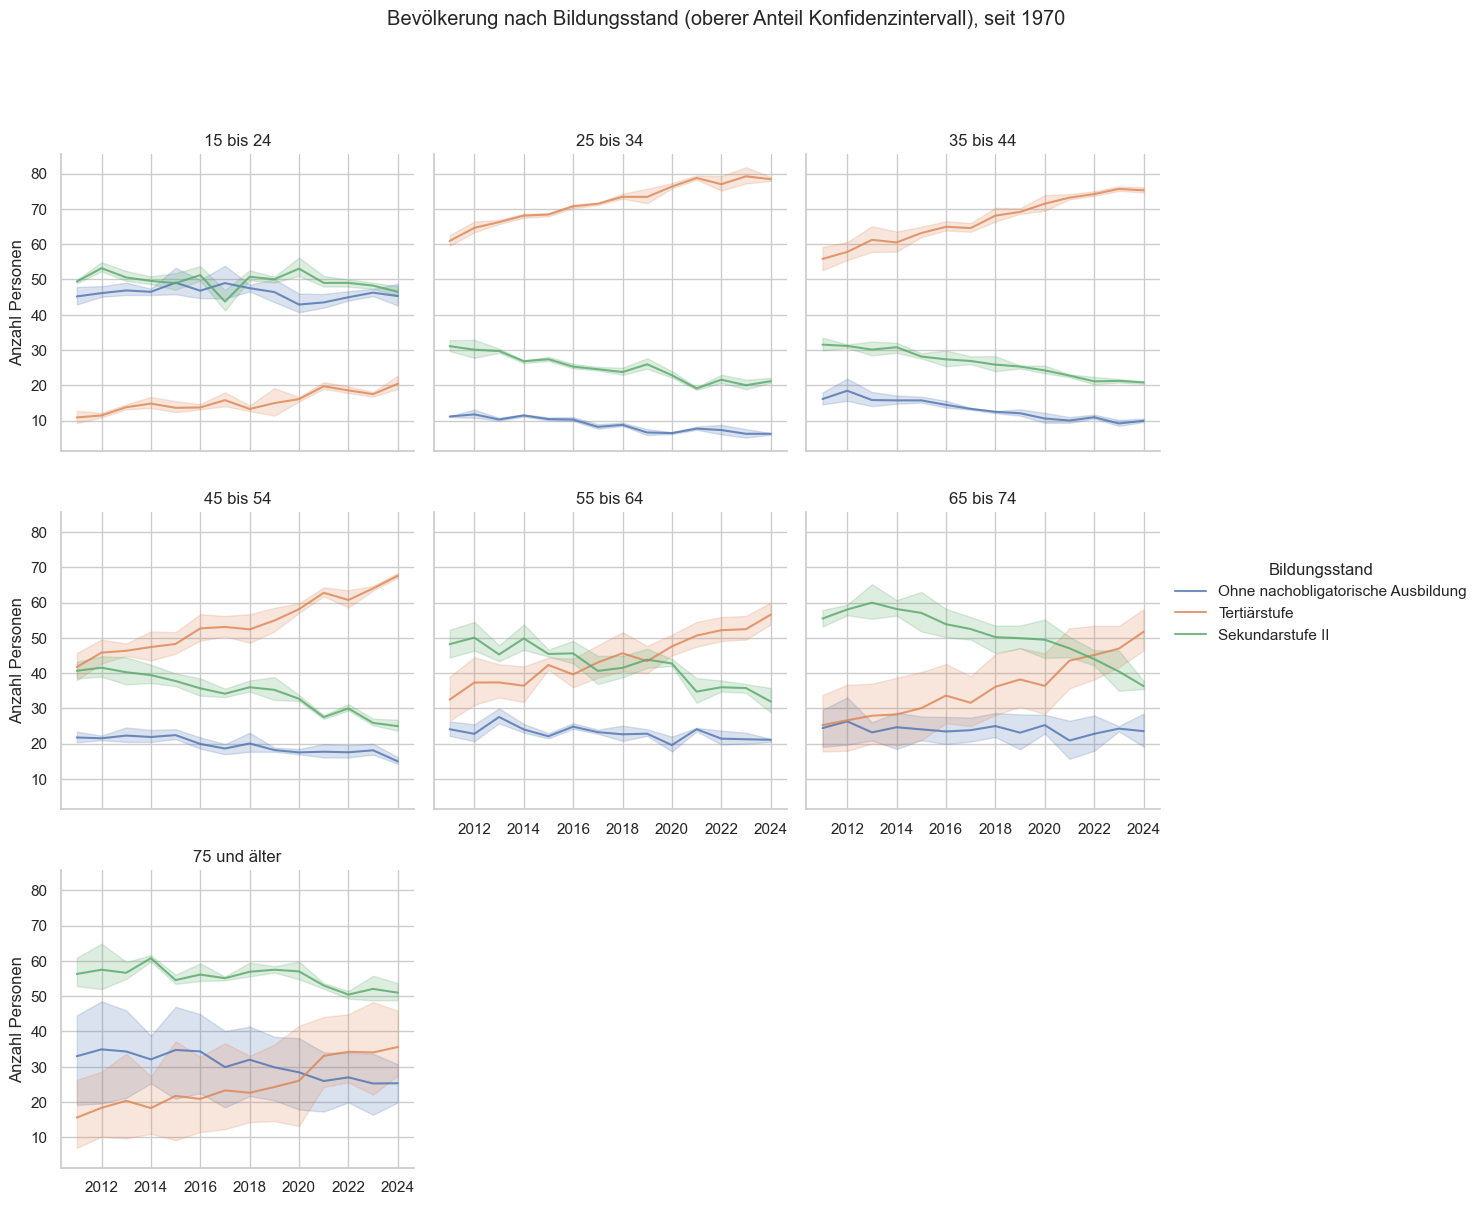

In [58]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('AlterV10_15ueber75Lang_noDM', ascending=True)
    ,col = "AlterV10_15ueber75Lang_noDM"
    ,hue = "Bildungsstand"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_end"
    ,y = "untAntBevKI"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Bevölkerung nach Bildungsstand (unterer Anteil Konfidenzintervall), seit "+str(int(data2betested.index.year.min()))
)
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('AlterV10_15ueber75Lang_noDM', ascending=True)
    ,col = "AlterV10_15ueber75Lang_noDM"
    ,hue = "Bildungsstand"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_end"
    ,y = "obAntBevKI"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Bevölkerung nach Bildungsstand (oberer Anteil Konfidenzintervall), seit "+str(int(data2betested.index.year.min()))
)
faced_grid1, faced_grid2

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [40]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [59]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['AlterV10_15ueber75Lang_noDM'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', '15 bis 24': '#0017BF', '25 bis 34': '#0072D7', '35 bis 44': '#00A5D2', '45 bis 54': '#5E359A', '55 bis 64': '#BA0062', '65 bis 74': '#DA5563', '75 und älter': '#00615D'}


##### Bevölkerung nach Bildungsstand

In [42]:
data2betested.reset_index().columns

Index(['Jahr_end', 'Jahr', 'Geschlecht', 'AlterV10_15ueber75Lang_noDM', 'Bildungsstand', 'AntBev',
       'untAntBevKI', 'obAntBevKI', 'StichtagDatJahr_str', 'Jahr_nbr'],
      dtype='object')

In [66]:

myTM = data2betested.loc[data_max_date]  \
    .groupby(['Jahr', 'Jahr_end','Geschlecht', 'AlterV10_15ueber75Lang_noDM', 'Bildungsstand']) \
    .agg(mean_AntBev=('AntBev', 'mean')
        ,median_AntBev=('AntBev', 'median')
        ) \
    .sort_values('Jahr', ascending=True) 

myTM.reset_index().head(3)

,Jahr,Jahr_end,Geschlecht,AlterV10_15ueber75Lang_noDM,Bildungsstand,mean_AntBev,median_AntBev
0,2023-01-01,2023-12-31,Frauen,15 bis 24,Ohne nachobligatorische Ausbildung,38,38
1,2023-01-01,2023-12-31,Männer,55 bis 64,Ohne nachobligatorische Ausbildung,18,18
2,2023-01-01,2023-12-31,Männer,55 bis 64,Sekundarstufe II,26,26


In [68]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['Bildungsstand', 'Geschlecht','AlterV10_15ueber75Lang_noDM']
    ,values="median_AntBev"
    ,color="AlterV10_15ueber75Lang_noDM"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc 
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Bevölkerung nach Bildungsstand,  "+ data_max_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x00000254F1530890>, 'Bildungsstand', 'Geschlecht', 'AlterV10_15ueber75Lang_noDM']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=357&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------